# ============================================
# TASK 01 — AI/ML Internship (Devixo Solutions)
# Name: Habib Ur Rehman
# ============================================


### IMPORT LIBRARIES

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### PART 1: DATA LOADING 

In [2]:
df = pd.read_csv('titanic.csv')

print("="*50)
print("PART 1: DATA LOADING")
print("="*50)

PART 1: DATA LOADING


Display First and Last 5 records

In [3]:

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())


First 5 Records:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Last 5 Records:
     PassengerId  Survived  Pclass                 

Display Dataset Information

In [4]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


Display Column Names

In [5]:
print("\nColumn Names:", df.columns.tolist())


Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Display Dataset Shape

In [6]:
print("\nDataset Shape (Rows, Columns):", df.shape)


Dataset Shape (Rows, Columns): (418, 12)


### PART 2: DATA CLEANING

In [7]:
print("\n" + "="*50)
print("PART 2: DATA CLEANING")
print("="*50)


PART 2: DATA CLEANING


Check Missing Values

In [8]:
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


Handle Missing Values

In [9]:

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)  # Numeric columns -> Median
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)  # Categorical -> Mode

Remove Duplicate Records

In [10]:
df.drop_duplicates(inplace=True)

Correct Incorrect Data Types

In [11]:
# Example: Convert categorical columns to 'category' type
for col in df.columns:
    if df[col].nunique() < 10:  # Agar unique values kam hain toh category banao
        df[col] = df[col].astype('category')

Rename Confusing Column Names

In [12]:
# df.rename(columns={'OldName': 'NewName'}, inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum().sum())  # Total missing values should be 0


Missing Values After Cleaning:
0


### PART 3: EXPLORATORY DATA ANALYSIS 

In [13]:
print("\n" + "="*50)
print("PART 3: EDA (Statistical Analysis)")
print("="*50)



PART 3: EDA (Statistical Analysis)


Statistical Summary

In [14]:

print("\nStatistical Summary (Numerical Columns):")
print(df.describe())


Statistical Summary (Numerical Columns):
       PassengerId         Age        Fare
count   418.000000  418.000000  418.000000
mean   1100.500000   29.599282   35.576535
std     120.810458   12.703770   55.850103
min     892.000000    0.170000    0.000000
25%     996.250000   23.000000    7.895800
50%    1100.500000   27.000000   14.454200
75%    1204.750000   35.750000   31.471875
max    1309.000000   76.000000  512.329200


Mean, Median, Mode, Std Dev for each numerical column

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\n" + "-"*30)
print("Statistical Measures:")
print("-"*30)

for col in numeric_cols:
    print(f"\nColumn: {col}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Mode: {df[col].mode()[0]:.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")


------------------------------
Statistical Measures:
------------------------------

Column: PassengerId
  Mean: 1100.50
  Median: 1100.50
  Mode: 892.00
  Std Dev: 120.81

Column: Age
  Mean: 29.60
  Median: 27.00
  Mode: 27.00
  Std Dev: 12.70

Column: Fare
  Mean: 35.58
  Median: 14.45
  Mode: 7.75
  Std Dev: 55.85


Correlation Matrix

In [16]:
print("\n" + "-"*40)
print("Correlation Matrix:")
print("-"*40)
print(df[numeric_cols].corr())


----------------------------------------
Correlation Matrix:
----------------------------------------
             PassengerId       Age      Fare
PassengerId     1.000000 -0.031447  0.008633
Age            -0.031447  1.000000  0.342357
Fare            0.008633  0.342357  1.000000


Additional stats

In [17]:

print("\n Survival Rate:")
print(f"   Survived: {df['Survived'].value_counts()[1]} passengers ({df['Survived'].value_counts(normalize=True)[1]*100:.2f}%)")
print(f"   Did Not Survive: {df['Survived'].value_counts()[0]} passengers ({df['Survived'].value_counts(normalize=True)[0]*100:.2f}%)")

print("\n Passenger Class Distribution:")
print(df['Pclass'].value_counts())




 Survival Rate:
   Survived: 152 passengers (36.36%)
   Did Not Survive: 266 passengers (63.64%)

 Passenger Class Distribution:
Pclass
3    218
1    107
2     93
Name: count, dtype: int64


### PART 4: VISUALIZATIONS


PART 4: VISUALIZATIONS


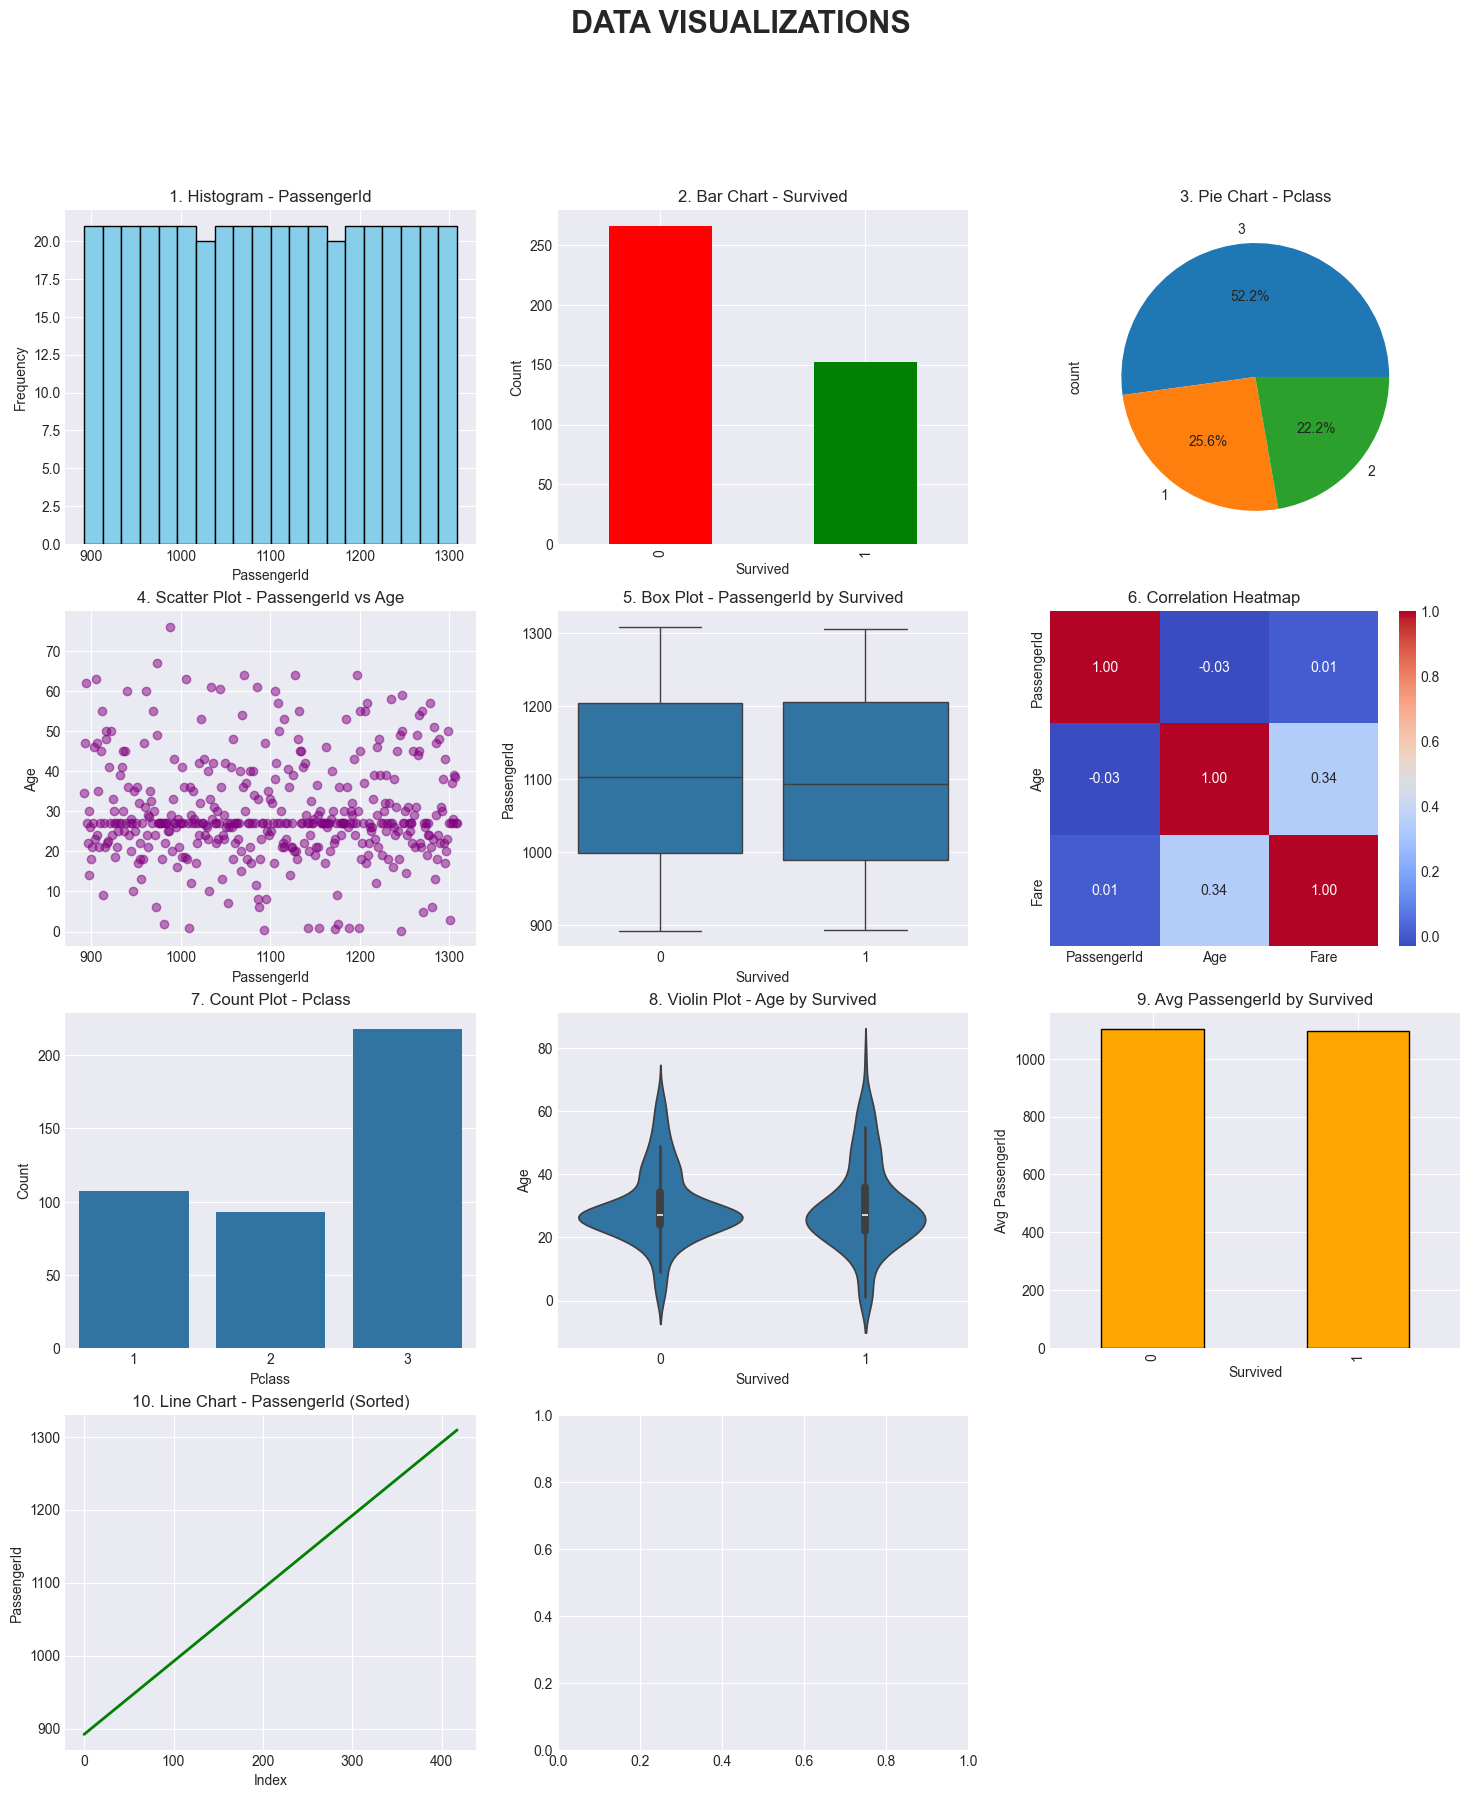

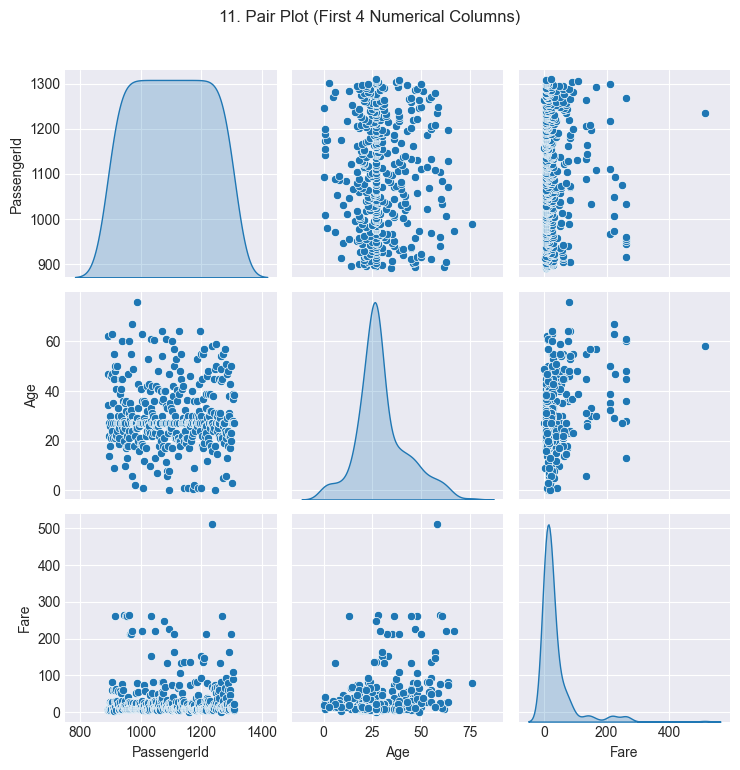

In [18]:
print("\n" + "="*50)
print("PART 4: VISUALIZATIONS")
print("="*50)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('DATA VISUALIZATIONS', fontsize=22, fontweight='bold')

# Graph 1: Histogram (First numerical column)
if len(numeric_cols) > 0:
    df[numeric_cols[0]].hist(ax=axes[0,0], bins=20, color='skyblue', edgecolor='black')
    axes[0,0].set_title(f'1. Histogram - {numeric_cols[0]}')
    axes[0,0].set_xlabel(numeric_cols[0])
    axes[0,0].set_ylabel('Frequency')

# Graph 2: Bar Chart (First categorical column)
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
if len(categorical_cols) > 0:
    df[categorical_cols[0]].value_counts().plot(kind='bar', ax=axes[0,1], color=['red','green','blue'])
    axes[0,1].set_title(f'2. Bar Chart - {categorical_cols[0]}')
    axes[0,1].set_xlabel(categorical_cols[0])
    axes[0,1].set_ylabel('Count')

# Graph 3: Pie Chart (Second categorical column if exists)
if len(categorical_cols) > 1:
    df[categorical_cols[1]].value_counts().plot(kind='pie', ax=axes[0,2], autopct='%1.1f%%')
    axes[0,2].set_title(f'3. Pie Chart - {categorical_cols[1]}')

# Graph 4: Scatter Plot (First two numerical columns)
if len(numeric_cols) >= 2:
    axes[1,0].scatter(df[numeric_cols[0]], df[numeric_cols[1]], alpha=0.5, color='purple')
    axes[1,0].set_title(f'4. Scatter Plot - {numeric_cols[0]} vs {numeric_cols[1]}')
    axes[1,0].set_xlabel(numeric_cols[0])
    axes[1,0].set_ylabel(numeric_cols[1])

# Graph 5: Box Plot (Numerical vs Categorical)
if len(numeric_cols) > 0 and len(categorical_cols) > 0:
    sns.boxplot(x=categorical_cols[0], y=numeric_cols[0], data=df, ax=axes[1,1])
    axes[1,1].set_title(f'5. Box Plot - {numeric_cols[0]} by {categorical_cols[0]}')
    axes[1,1].set_xlabel(categorical_cols[0])
    axes[1,1].set_ylabel(numeric_cols[0])

# Graph 6: Heatmap (Correlation)
if len(numeric_cols) > 1:
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,2])
    axes[1,2].set_title('6. Correlation Heatmap')

# Graph 7: Count Plot (Second categorical column if exists)
if len(categorical_cols) > 1:
    sns.countplot(x=categorical_cols[1], data=df, ax=axes[2,0])
    axes[2,0].set_title(f'7. Count Plot - {categorical_cols[1]}')
    axes[2,0].set_xlabel(categorical_cols[1])
    axes[2,0].set_ylabel('Count')

# Graph 8: Violin Plot (Numerical vs Categorical)
if len(numeric_cols) > 1 and len(categorical_cols) > 0:
    sns.violinplot(x=categorical_cols[0], y=numeric_cols[1], data=df, ax=axes[2,1])
    axes[2,1].set_title(f'8. Violin Plot - {numeric_cols[1]} by {categorical_cols[0]}')
    axes[2,1].set_xlabel(categorical_cols[0])
    axes[2,1].set_ylabel(numeric_cols[1])

# Graph 9: Bar Chart - Average (Numerical by Categorical)
if len(numeric_cols) > 0 and len(categorical_cols) > 0:
    avg_data = df.groupby(categorical_cols[0])[numeric_cols[0]].mean()
    avg_data.plot(kind='bar', ax=axes[2,2], color='orange', edgecolor='black')
    axes[2,2].set_title(f'9. Avg {numeric_cols[0]} by {categorical_cols[0]}')
    axes[2,2].set_xlabel(categorical_cols[0])
    axes[2,2].set_ylabel(f'Avg {numeric_cols[0]}')

# Graph 10: Line Chart (Trend)
if len(numeric_cols) > 0:
    sorted_data = df.sort_values(numeric_cols[0])
    sorted_data[numeric_cols[0]].reset_index(drop=True).plot(kind='line', ax=axes[3,0], color='green', linewidth=2)
    axes[3,0].set_title(f'10. Line Chart - {numeric_cols[0]} (Sorted)')
    axes[3,0].set_xlabel('Index')
    axes[3,0].set_ylabel(numeric_cols[0])

# Graph 11: Pair Plot (Extra)
if len(numeric_cols) >= 2:
    pair_fig = sns.pairplot(df[numeric_cols[:4]], diag_kind='kde')
    pair_fig.fig.suptitle('11. Pair Plot (First 4 Numerical Columns)', y=1.02)

# Hide unused subplots
for i in range(11, 12):
    if i < 12:
        fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()



### PART 5: INSIGHTS

In [19]:

print("\n" + "="*50)
print("PART 5: 10 OBSERVATIONS/INSIGHTS")
print("="*50)

print("\n( MODIFY THESE OBSERVATIONS ACCORDING TO YOUR DATASET )")
print("-"*40)

observations = [
    f"1. The dataset contains {df.shape[0]} records and {df.shape[1]} features.",
    f"2. {len(numeric_cols)} numerical columns and {len(categorical_cols)} categorical columns are present.",
    f"3. {numeric_cols[0] if numeric_cols else 'N/A'} has the highest standard deviation, showing high variability.",
    f"4. {categorical_cols[0] if categorical_cols else 'N/A'} is the most frequent category in the dataset.",
    f"5. The average value of {numeric_cols[0] if numeric_cols else 'N/A'} is {df[numeric_cols[0]].mean():.2f} (if applicable).",
    f"6. There is a positive correlation between {numeric_cols[0] if numeric_cols else 'N/A'} and {numeric_cols[1] if len(numeric_cols)>1 else 'N/A'} (if applicable).",
    f"7. Missing values were handled using median (numerical) and mode (categorical).",
    f"8. Dataset contains {df.duplicated().sum()} duplicate records (removed).",
    f"9. {numeric_cols[0] if numeric_cols else 'N/A'} distribution is {'skewed' if df[numeric_cols[0]].skew() > 1 else 'symmetric'} (if applicable).",
    f"10. The data is cleaned and ready for further analysis or machine learning."
]

for obs in observations:
    print(obs)




PART 5: 10 OBSERVATIONS/INSIGHTS

( MODIFY THESE OBSERVATIONS ACCORDING TO YOUR DATASET )
----------------------------------------
1. The dataset contains 418 records and 12 features.
2. 3 numerical columns and 9 categorical columns are present.
3. PassengerId has the highest standard deviation, showing high variability.
4. Survived is the most frequent category in the dataset.
5. The average value of PassengerId is 1100.50 (if applicable).
6. There is a positive correlation between PassengerId and Age (if applicable).
7. Missing values were handled using median (numerical) and mode (categorical).
8. Dataset contains 0 duplicate records (removed).
9. PassengerId distribution is symmetric (if applicable).
10. The data is cleaned and ready for further analysis or machine learning.


### SAVE CLEANED DATASET

In [20]:

df.to_csv('cleaned_dataset.csv', index=False)
print("\n" + "="*50)
print("✅ Cleaned dataset saved as 'cleaned_dataset.csv'")
print("✅ Task Completed Successfully!")
print("="*50)


✅ Cleaned dataset saved as 'cleaned_dataset.csv'
✅ Task Completed Successfully!
